## Importing Libraries and the Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import KFold, cross_val_score


In [2]:
train_raw = pd.read_csv("train.csv")
test_raw  = pd.read_csv("test.csv")
submission = pd.read_csv("submission.csv")

print("Train set — first 5 rows:")
train_raw.head()

Train set — first 5 rows:


,ID,date,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category,food_waste_kg
0,0,2022-12-19,196,13,27.887273,45.362854,0,0,7.740587,intermediate,dairy,28.946465
1,1,2023-11-21,244,15,10.317872,64.430475,1,0,42.311779,NaN,MeAt,51.549053
2,4,2022-02-01,148,16,27.714300,69.046113,1,0,41.184305,Beginner,MeAt,53.008323
3,5,2023-03-19,157,19,19.173902,46.292823,6,0,41.543492,Beginner,MeAt,48.621527
4,6,2022-07-18,297,10,26.375233,79.741064,0,0,26.525097,Intermediate,MEAT,44.156984


## Dataset Overview

In [3]:
shape = train_raw.shape
print("Samples  (Rows) :", shape[0])
print("Features (Cols) :", shape[1])

Samples  (Rows) : 911
Features (Cols) : 12


In [4]:
train_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                911 non-null    int64  
 1   date              911 non-null    str    
 2   meals_served      911 non-null    int64  
 3   kitchen_staff     911 non-null    int64  
 4   temperature_C     911 non-null    float64
 5   humidity_percent  911 non-null    float64
 6   day_of_week       911 non-null    int64  
 7   special_event     911 non-null    int64  
 8   past_waste_kg     911 non-null    float64
 9   staff_experience  747 non-null    str    
 10  waste_category    911 non-null    str    
 11  food_waste_kg     911 non-null    float64
dtypes: float64(4), int64(5), str(3)
memory usage: 85.5 KB


In [5]:
# Numerical features
numerical_data     = train_raw.select_dtypes(include='number')
numerical_features = numerical_data.columns.tolist()
print("Numerical features:", numerical_features)

Numerical features: ['ID', 'meals_served', 'kitchen_staff', 'temperature_C', 'humidity_percent', 'day_of_week', 'special_event', 'past_waste_kg', 'food_waste_kg']


In [6]:
# Categorical features
categorical_data     = train_raw.select_dtypes(include='object')
categorical_features = categorical_data.columns.tolist()
print("Categorical features:", categorical_features)

Categorical features: ['date', 'staff_experience', 'waste_category']


In [7]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,911.0,528.327113,305.072794,0.000000,266.000000,531.000000,795.500000,1049.000000
meals_served,911.0,375.405049,502.812717,100.000000,211.000000,306.000000,407.000000,4730.000000
kitchen_staff,911.0,11.900110,4.285153,5.000000,8.000000,12.000000,15.000000,19.000000
temperature_C,911.0,22.189280,8.922389,-10.372207,15.684585,22.115040,28.804294,60.000000
humidity_percent,911.0,60.761313,17.330821,30.121111,46.017835,61.633960,75.787910,89.982828
day_of_week,911.0,3.014270,2.009542,0.000000,1.000000,3.000000,5.000000,6.000000
special_event,911.0,0.085620,0.279956,0.000000,0.000000,0.000000,0.000000,1.000000
past_waste_kg,911.0,27.015691,12.774223,5.008394,16.091383,26.854109,38.149878,49.803703
food_waste_kg,911.0,44.842691,27.934366,10.819048,32.887912,41.146930,50.046681,274.328783


In [8]:
categorical_data.describe().T

,count,unique,top,freq
date,911,867,2022-02-01,2
staff_experience,747,4,Beginner,191
waste_category,911,5,MEAT,210


## Correlation of Features

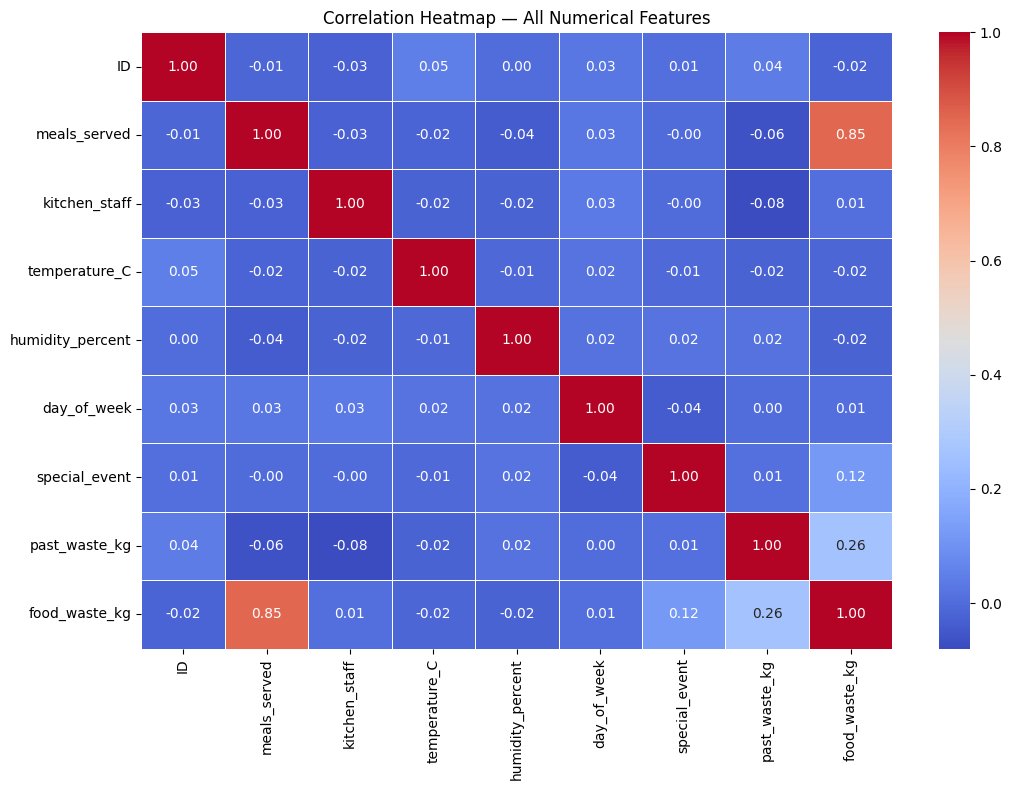

In [9]:
correlation_matrix = numerical_data.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap — All Numerical Features")
plt.tight_layout()
plt.show()

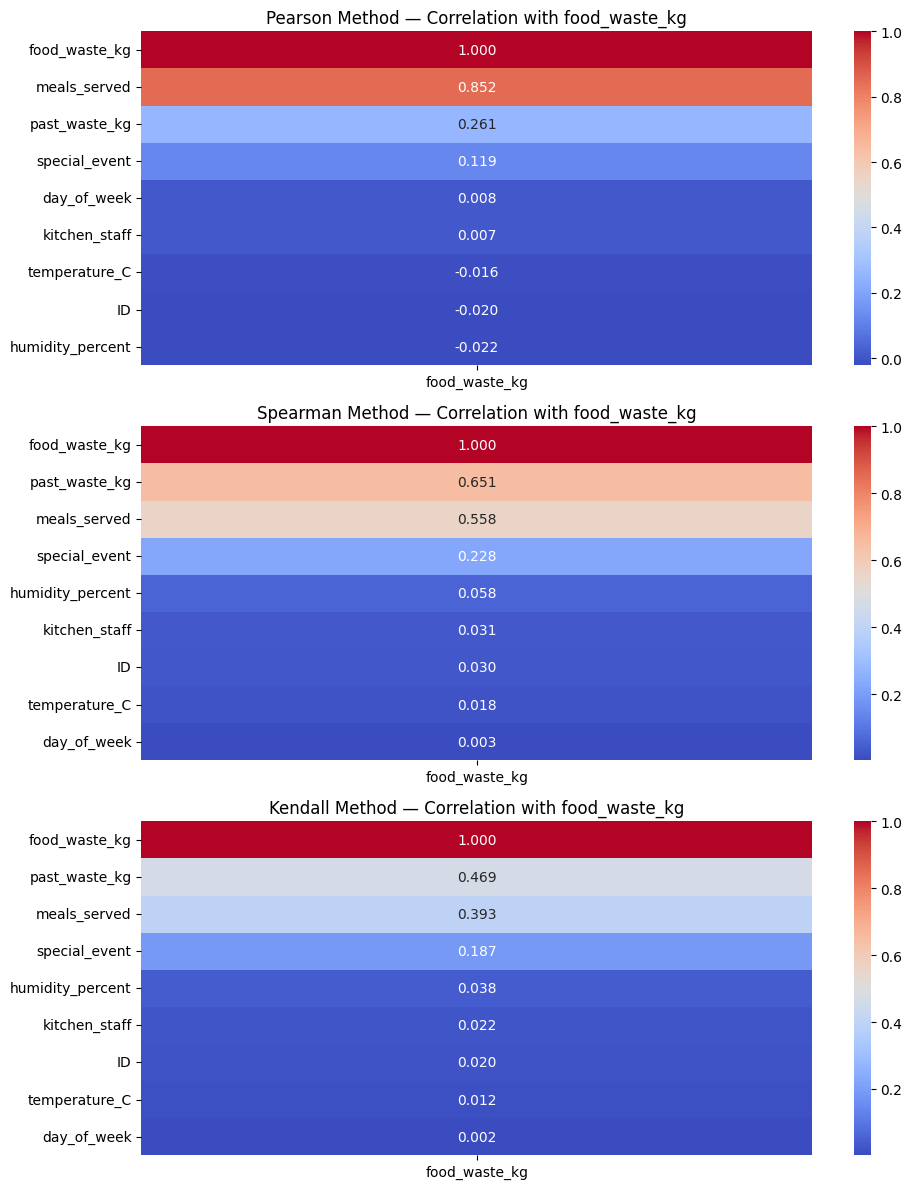

In [10]:
# Pearson, Spearman, Kendall correlations with food_waste_kg
fig, ax = plt.subplots(3, 1, figsize=(10, 12))

corr1 = numerical_data.corr('pearson')[['food_waste_kg']].sort_values(by='food_waste_kg', ascending=False)
corr2 = numerical_data.corr('spearman')[['food_waste_kg']].sort_values(by='food_waste_kg', ascending=False)
corr3 = numerical_data.corr('kendall')[['food_waste_kg']].sort_values(by='food_waste_kg', ascending=False)

ax[0].set_title('Pearson Method — Correlation with food_waste_kg')
ax[1].set_title('Spearman Method — Correlation with food_waste_kg')
ax[2].set_title('Kendall Method — Correlation with food_waste_kg')

sns.heatmap(corr1, ax=ax[0], annot=True, cmap='coolwarm', fmt='.3f')
sns.heatmap(corr2, ax=ax[1], annot=True, cmap='coolwarm', fmt='.3f')
sns.heatmap(corr3, ax=ax[2], annot=True, cmap='coolwarm', fmt='.3f')

plt.tight_layout()
plt.show()

## Imbalanced Dataset

    Range  Count  Percentage
  0–25 kg     87        9.55
 25–50 kg    595       65.31
 50–75 kg    205       22.50
75–100 kg      1        0.11
  >100 kg     23        2.52


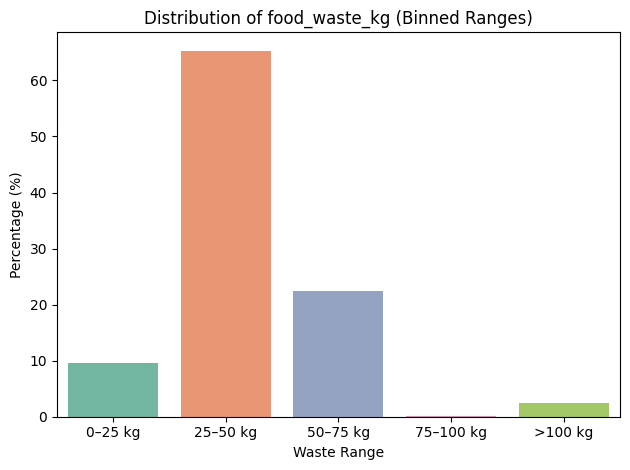

In [11]:
# Target variable distribution
total    = len(train_raw)
bins     = [0, 25, 50, 75, 100, float('inf')]
labels   = ['0–25 kg', '25–50 kg', '50–75 kg', '75–100 kg', '>100 kg']
binned   = pd.cut(train_raw['food_waste_kg'], bins=bins, labels=labels)
bin_counts = binned.value_counts().sort_index()

imbalance_df = pd.DataFrame({
    'Range': labels,
    'Count': bin_counts.values,
    'Percentage': (bin_counts.values / total * 100).round(2)
})
print(imbalance_df.to_string(index=False))

sns.barplot(data=imbalance_df, x='Range', y='Percentage', palette='Set2')
plt.title("Distribution of food_waste_kg (Binned Ranges)")
plt.xlabel("Waste Range")
plt.ylabel("Percentage (%)")
plt.tight_layout()
plt.show()

  Category  Count  Percentage
     DAIRY    180       19.76
    GRAINS    176       19.32
      MEAT    379       41.60
VEGETABLES    176       19.32


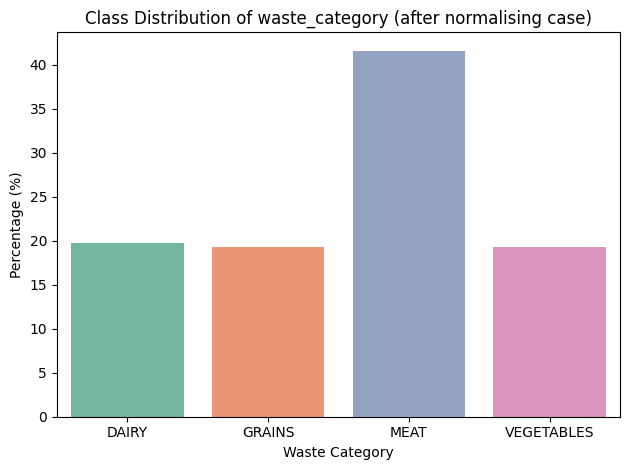

In [12]:
# Balance of waste_category (normalised — dirty values merged)
wc_counts = train_raw['waste_category'].str.upper().value_counts().sort_index()
wc_df = pd.DataFrame({
    'Category': wc_counts.index,
    'Count': wc_counts.values,
    'Percentage': (wc_counts.values / total * 100).round(2)
})
print(wc_df.to_string(index=False))

sns.barplot(data=wc_df, x='Category', y='Percentage', palette='Set2')
plt.title("Class Distribution of waste_category (after normalising case)")
plt.xlabel("Waste Category")
plt.ylabel("Percentage (%)")
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)

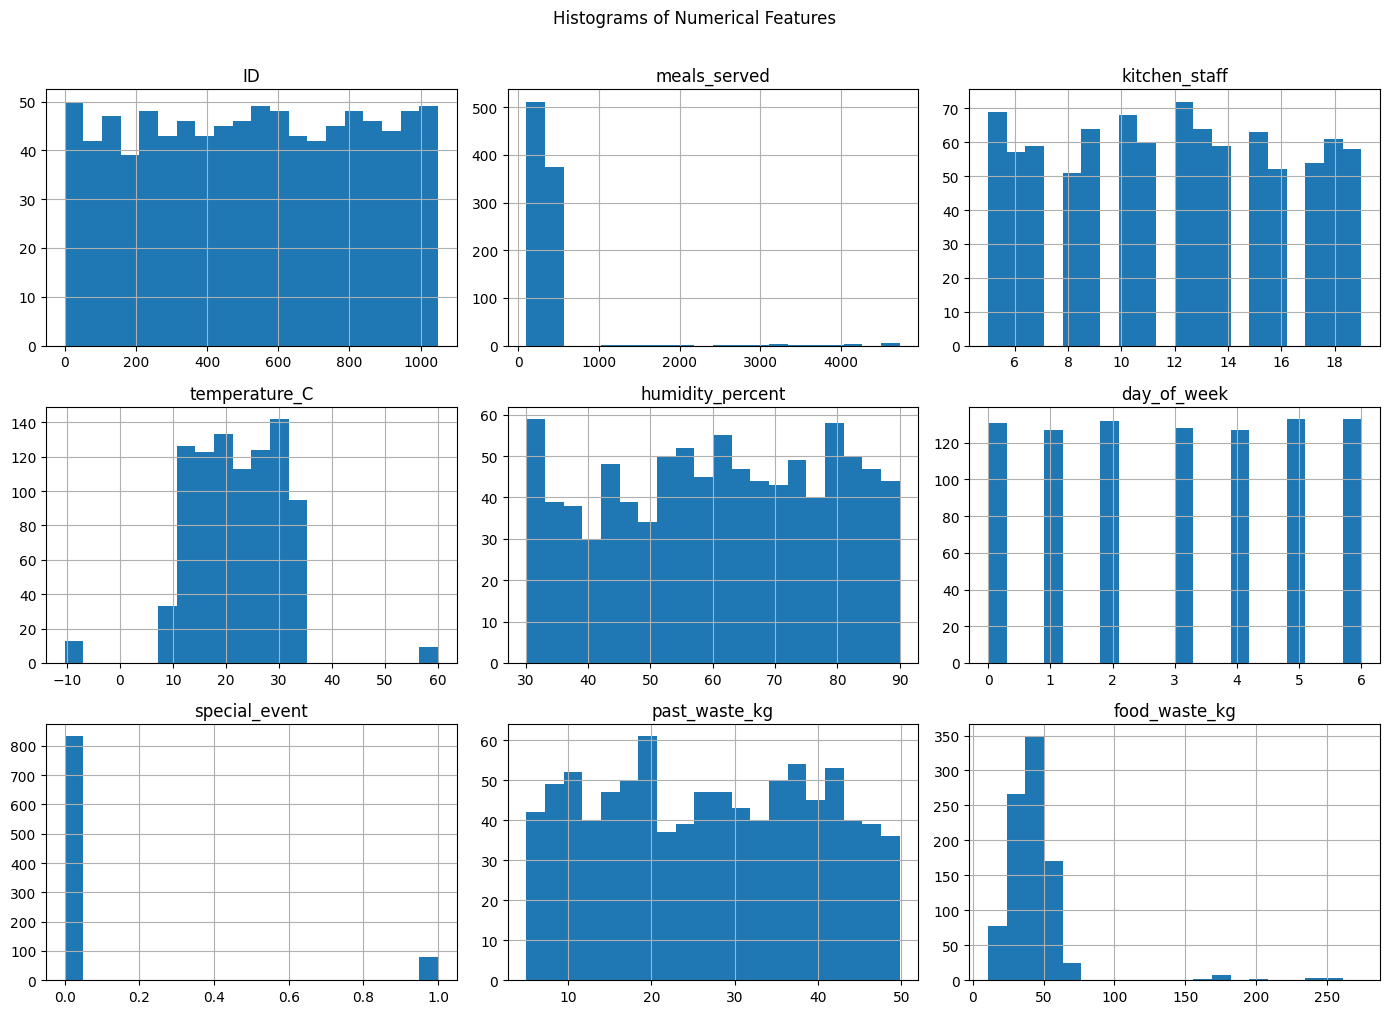

In [13]:
# Histograms — distribution of numerical features
numerical_data.hist(figsize=(14, 10), bins=20)
plt.suptitle("Histograms of Numerical Features", y=1.01)
plt.tight_layout()
plt.show()

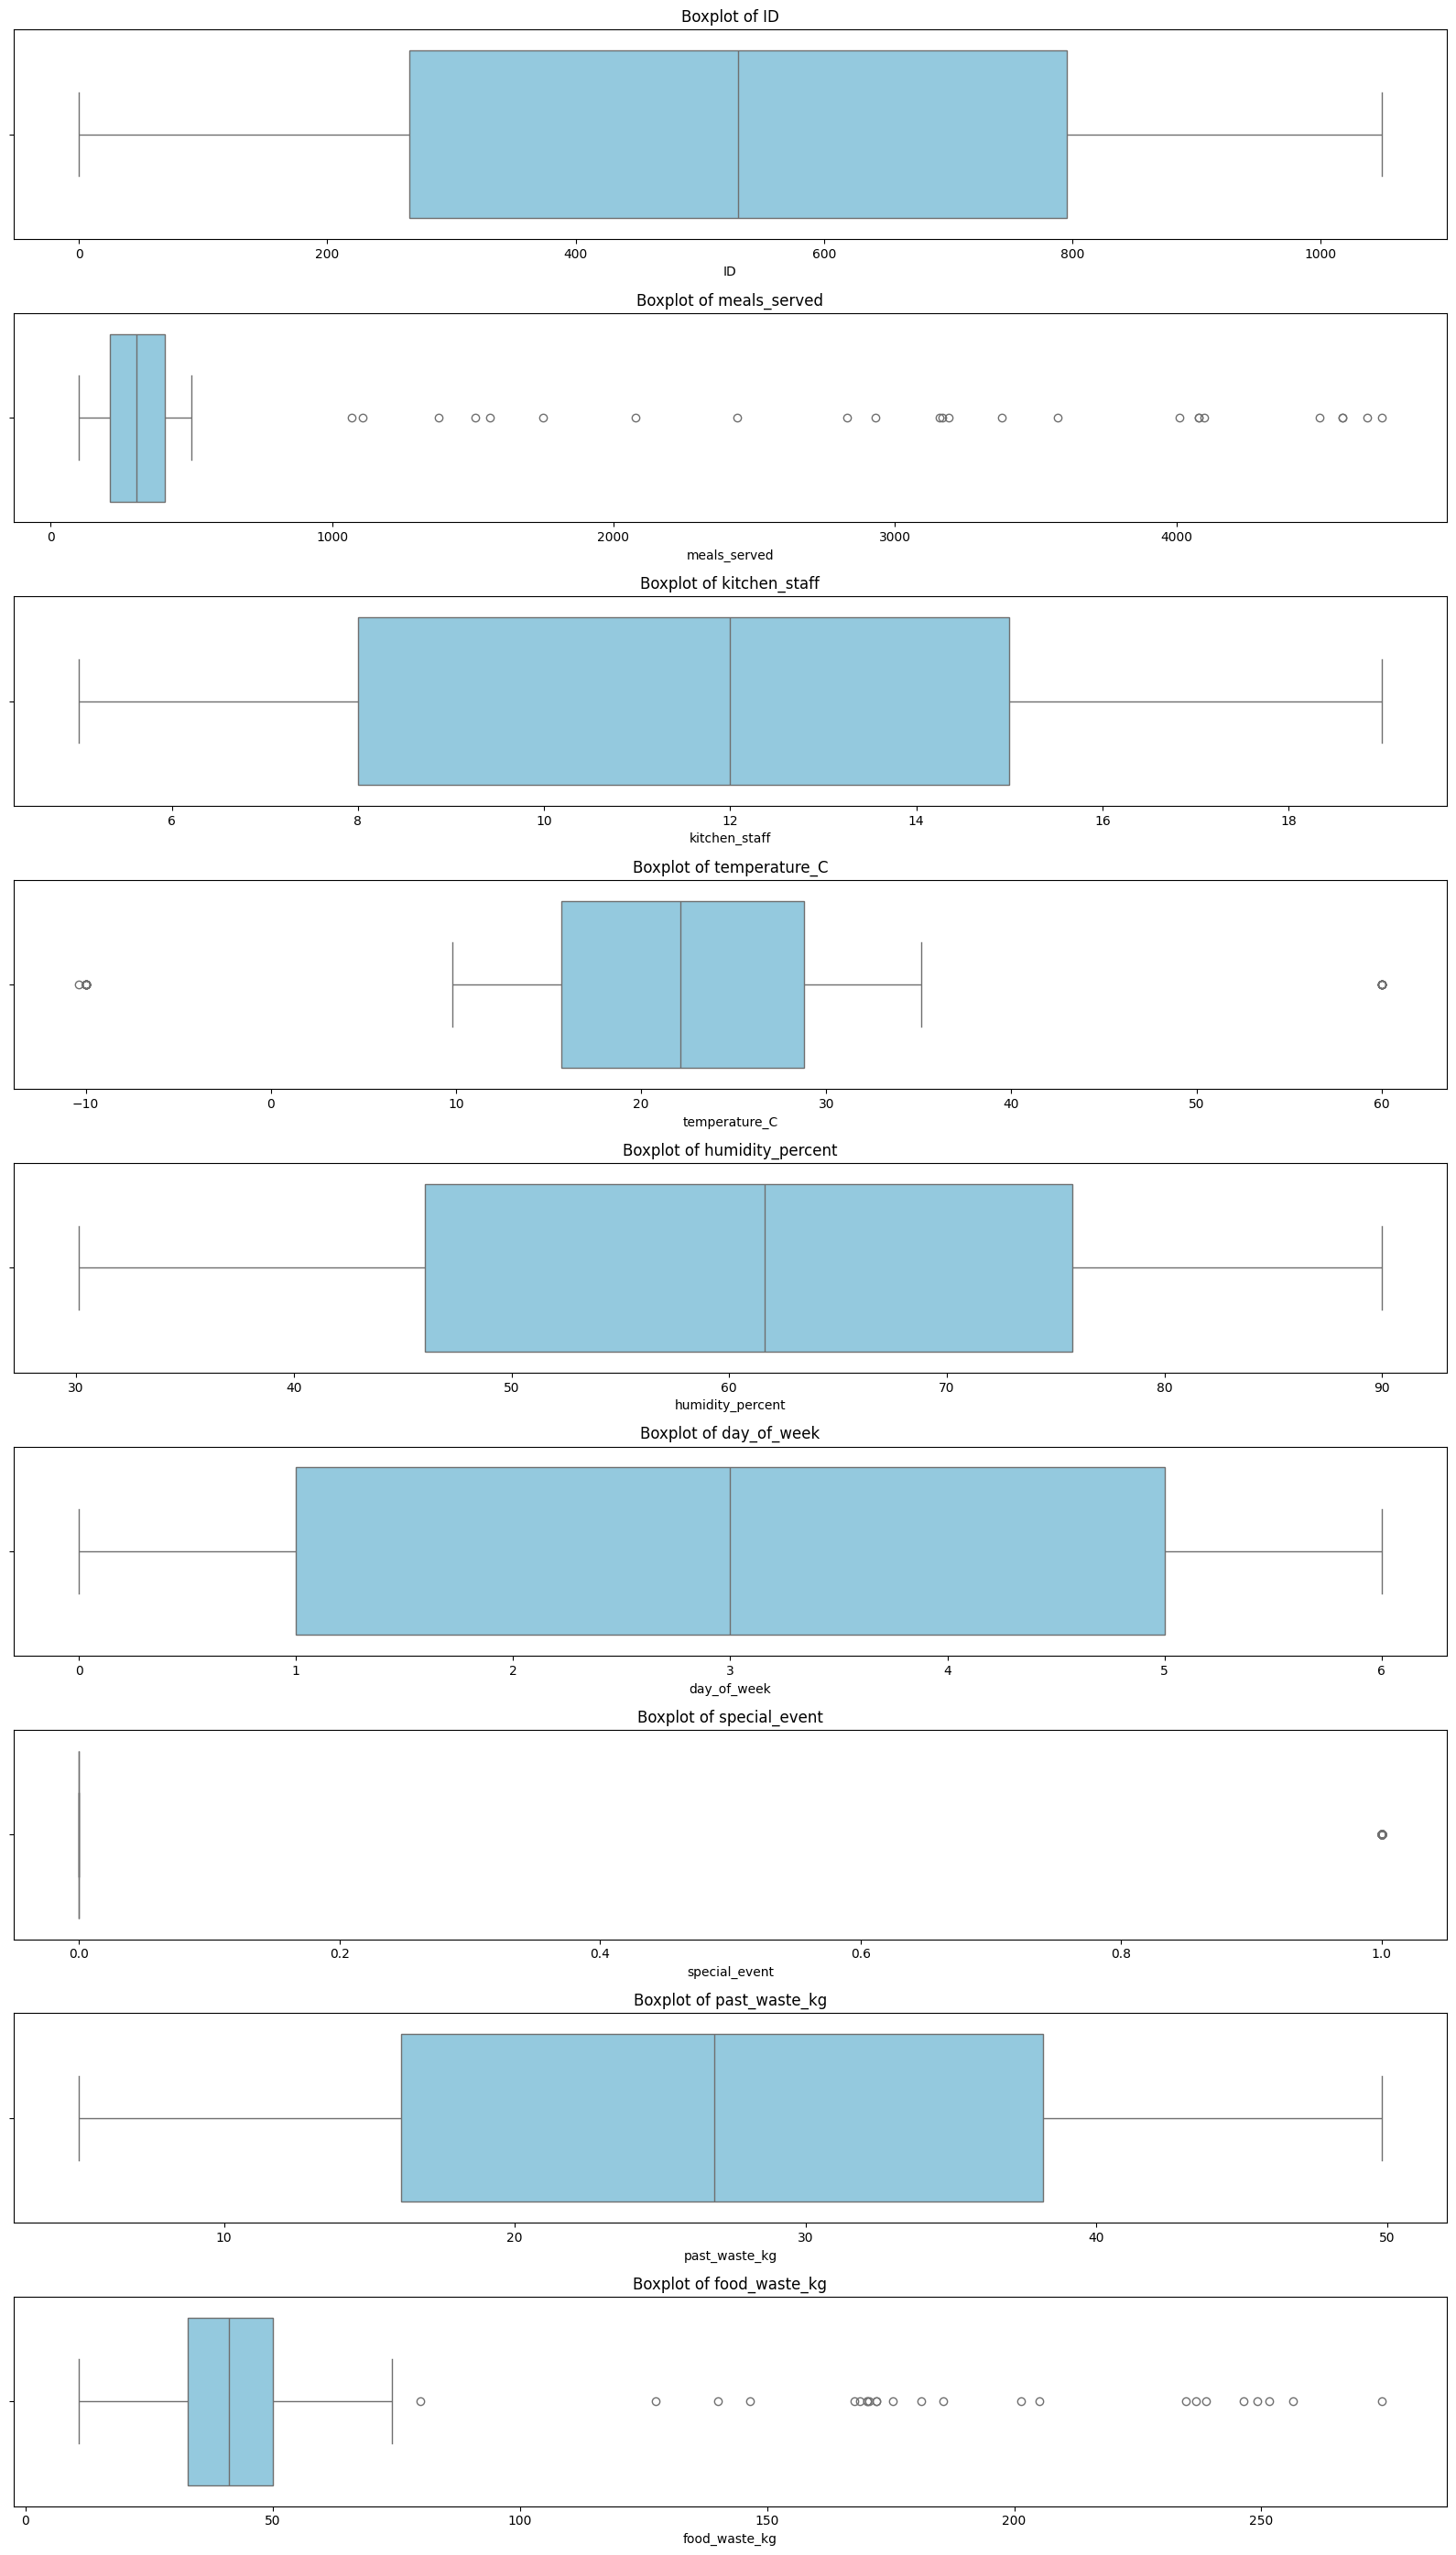

Note: Outliers detected in 'food_waste_kg' and 'meals_served'.


In [14]:
# Boxplots — detecting outliers
numeric_cols = train_raw.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(16, 28))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=train_raw[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
plt.tight_layout()
plt.show()
print("Note: Outliers detected in 'food_waste_kg' and 'meals_served'.")

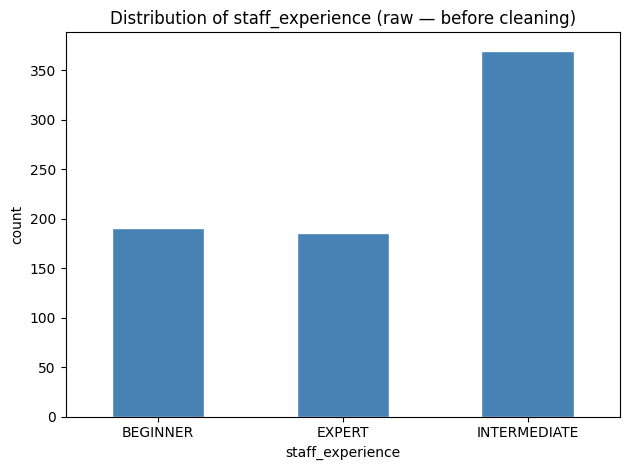

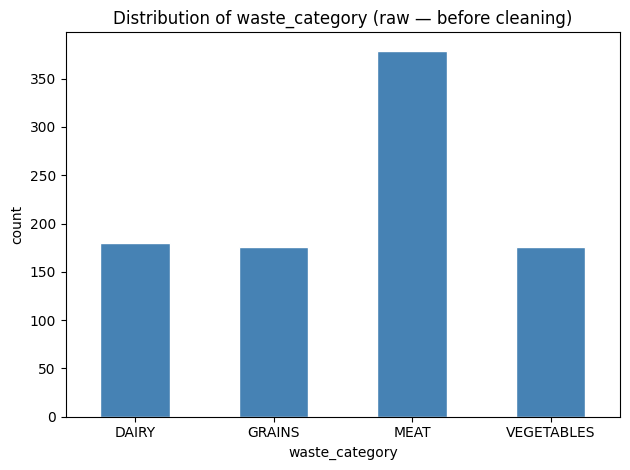

In [15]:
# Bar charts for categorical features
for col in categorical_features:
    if col == 'date':
        continue
    plt.figure()
    train_raw[col].str.upper().value_counts().sort_index().plot(
        kind='bar', rot=0, xlabel=col, ylabel='count', color='steelblue', edgecolor='white')
    plt.title(f'Distribution of {col} (raw — before cleaning)')
    plt.tight_layout()
    plt.show()

In [16]:
# Unique value counts
print("Unique value counts:\n")
print("Numerical features:\n", numerical_data.nunique(), "\n")
print("Categorical features:\n", categorical_data.nunique())

Unique value counts:

Numerical features:
 ID                  911
meals_served        373
kitchen_staff        15
temperature_C       892
humidity_percent    867
day_of_week           7
special_event         2
past_waste_kg       867
food_waste_kg       867
dtype: int64 

Categorical features:
 date                867
staff_experience      4
waste_category        5
dtype: int64


In [17]:
# Variance of numerical features
print("Variance of each numerical feature:\n")
print(numerical_data.var())

Variance of each numerical feature:

ID                   93069.409363
meals_served        252820.628062
kitchen_staff           18.362538
temperature_C           79.609032
humidity_percent       300.357363
day_of_week              4.038258
special_event            0.078375
past_waste_kg          163.180761
food_waste_kg          780.328817
dtype: float64


In [18]:
# Skewness of numerical features
print("Skewness of each numerical feature:\n")
print(numerical_data.skew())
print()
print("Interpretation of Skewness:")
print("  ~0         : Symmetrical (normal-ish)")
print("  0 to +/-0.5: Fairly symmetrical")
print("  0.5 to 1   : Moderately skewed")
print("  > 1        : Highly skewed")

Skewness of each numerical feature:

ID                 -0.015749
meals_served        6.581128
kitchen_staff       0.020202
temperature_C       0.111854
humidity_percent   -0.093234
day_of_week        -0.008186
special_event       2.966833
past_waste_kg       0.016268
food_waste_kg       4.990900
dtype: float64

Interpretation of Skewness:
  ~0         : Symmetrical (normal-ish)
  0 to +/-0.5: Fairly symmetrical
  0.5 to 1   : Moderately skewed
  > 1        : Highly skewed


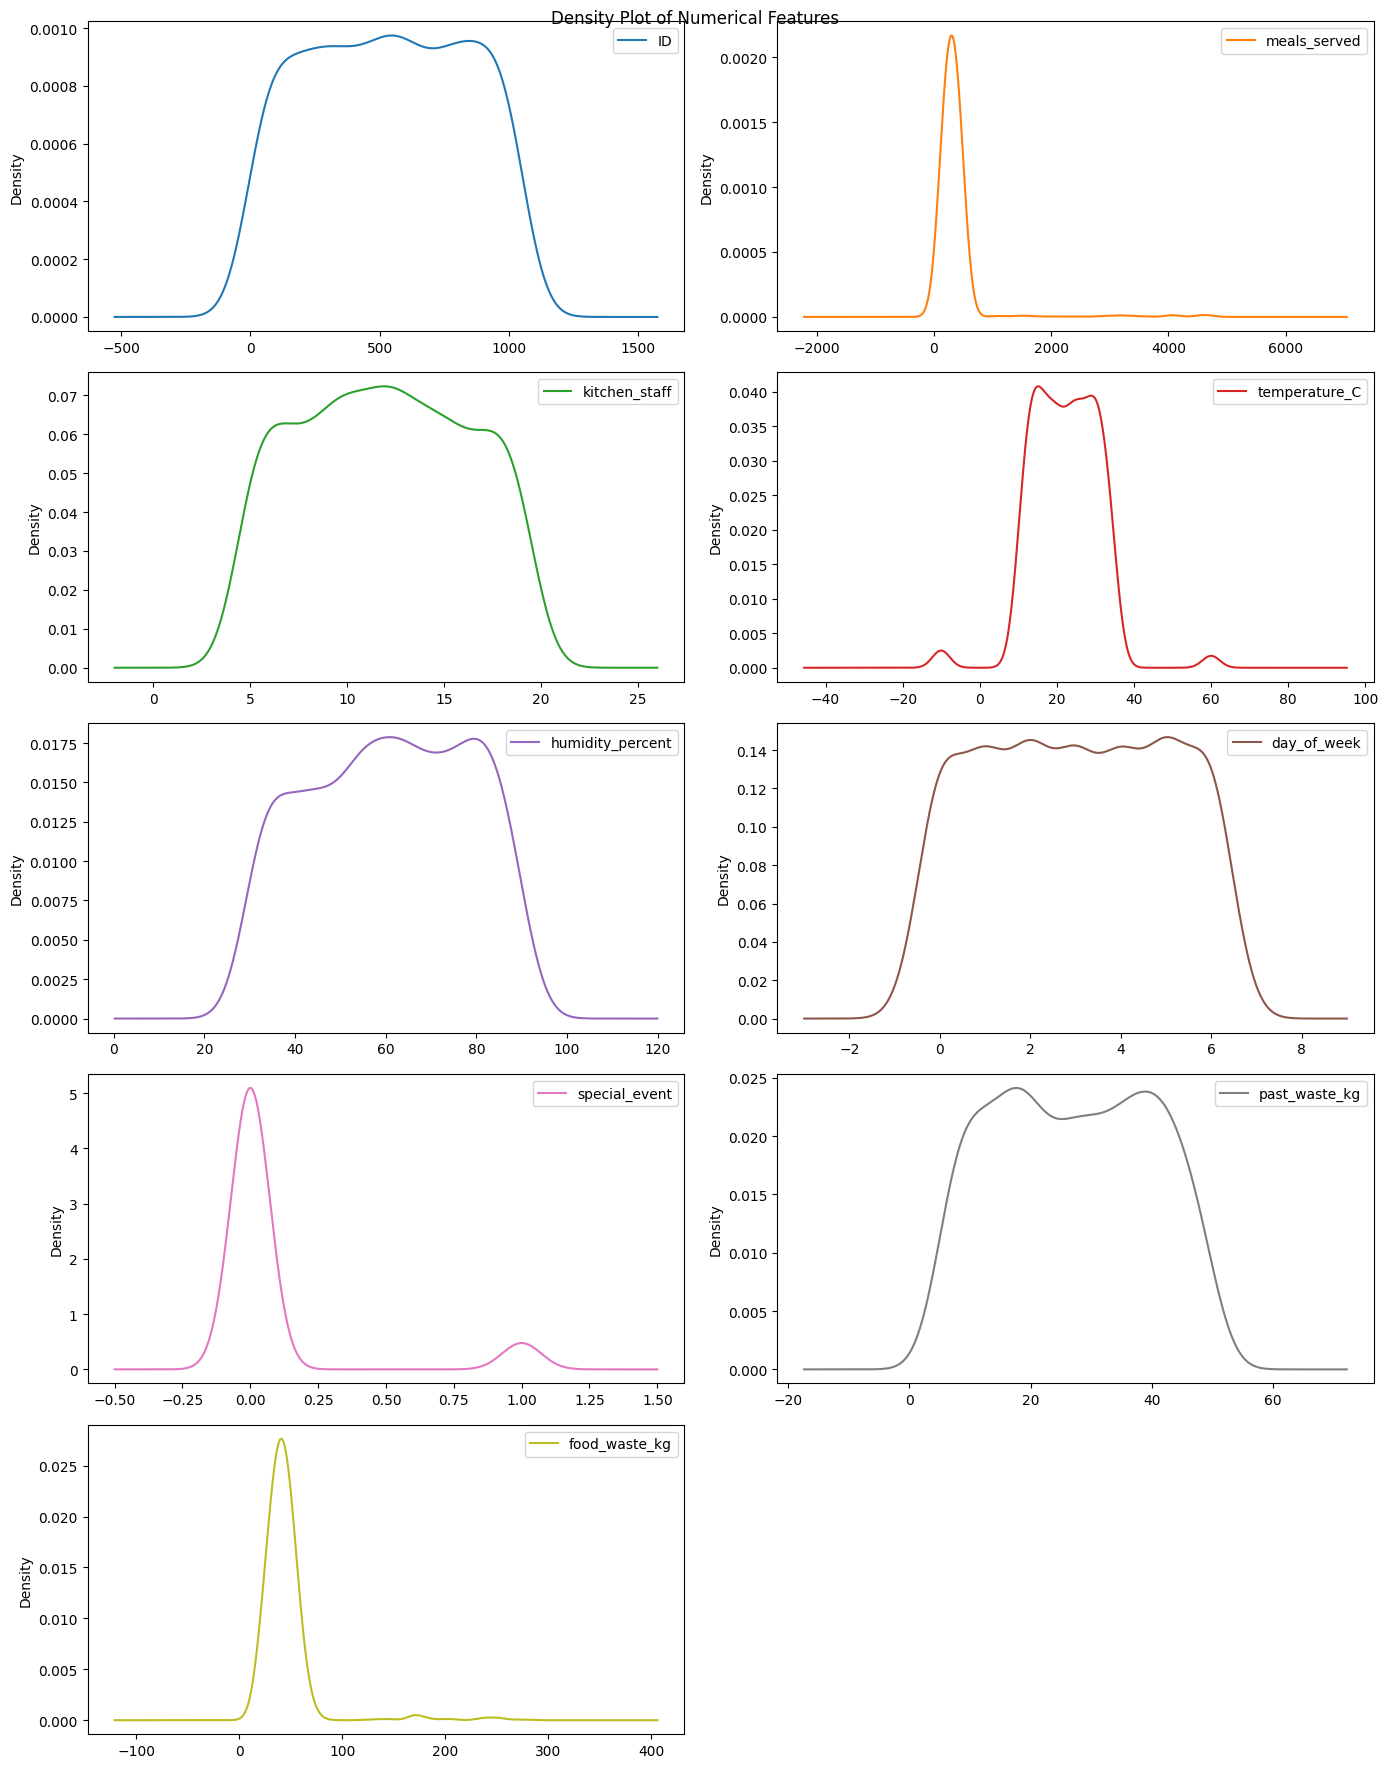

In [19]:
# Density plots of numerical features
numerical_data.plot(
    kind='density', figsize=(14, 18),
    subplots=True, layout=(5, 2),
    title="Density Plot of Numerical Features",
    sharex=False
)
plt.tight_layout()
plt.show()

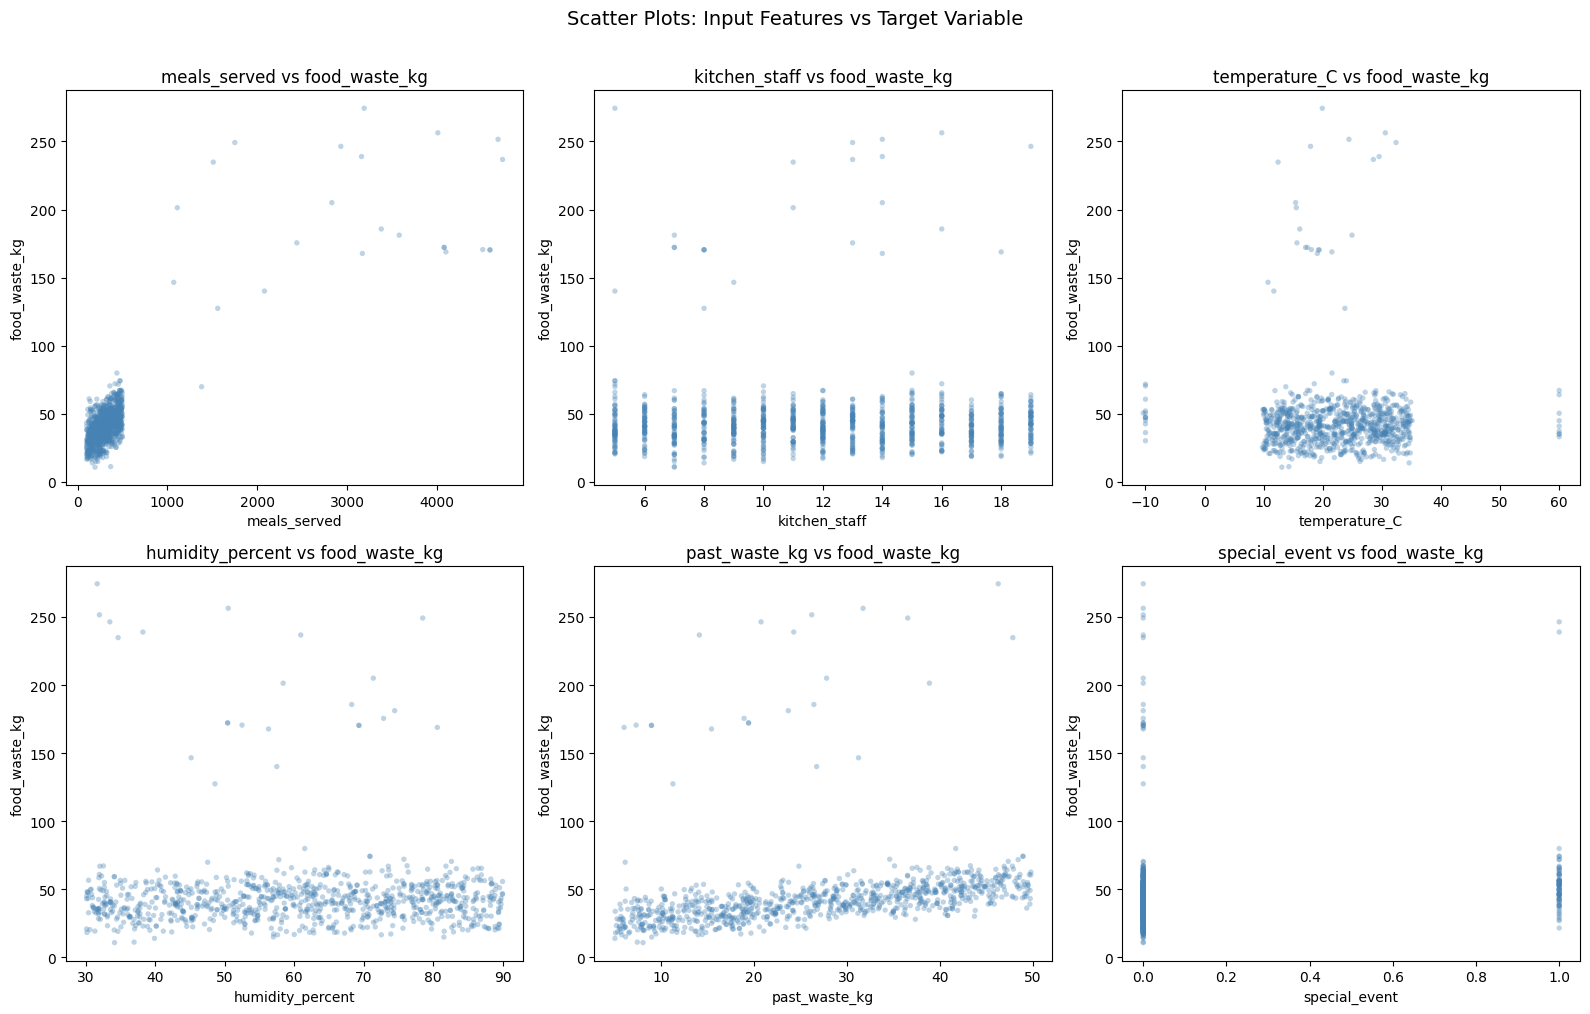

In [20]:
# Scatter plots — key numerical features vs target (food_waste_kg)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

scatter_features = ['meals_served', 'kitchen_staff', 'temperature_C',
                    'humidity_percent', 'past_waste_kg', 'special_event']

for i, feat in enumerate(scatter_features):
    axes[i].scatter(train_raw[feat], train_raw['food_waste_kg'],
                    alpha=0.35, s=15, color='steelblue', edgecolors='none')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('food_waste_kg')
    axes[i].set_title(f'{feat} vs food_waste_kg')

plt.suptitle("Scatter Plots: Input Features vs Target Variable", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [21]:
# Cramér's V — association between categorical features and the binned target
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - (r-1)**2/(n-1)
    kcorr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Bin food_waste_kg for chi-square test
bins = [0, 25, 50, 75, 100, float('inf')]
labels = ['0-25', '25-50', '50-75', '75-100', '>100']
target_binned = pd.cut(train_raw['food_waste_kg'], bins=bins, labels=labels)

cv_results = {}
for col in categorical_features:
    cv = cramers_v(train_raw[col].str.upper(), target_binned)
    cv_results[col] = round(cv, 4)

print("Cramér's V — Categorical Features vs food_waste_kg (binned):")
for feat, v in cv_results.items():
    print(f"  {feat:25s}: {v:.4f}  {'(strong)' if v > 0.3 else '(moderate)' if v > 0.1 else '(weak)'}")


Cramér's V — Categorical Features vs food_waste_kg (binned):
  date                     : 0.2204  (moderate)
  staff_experience         : 0.0424  (weak)
  waste_category           : 0.0000  (weak)


Point-Biserial Correlation (special_event vs food_waste_kg):
  r  = 0.1188
  p  = 0.0003  (statistically significant (p<0.05))

Interpretation: A positive r means days with a special event tend to have
higher food waste on average compared to non-event days.


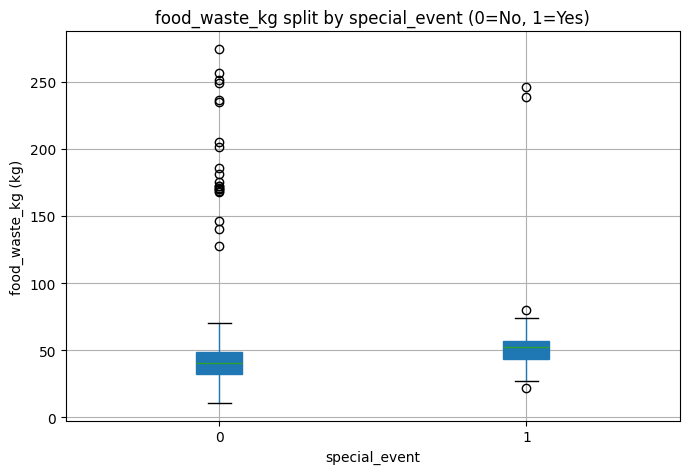

In [22]:
# Point-Biserial Correlation — binary feature 'special_event' vs food_waste_kg
from scipy.stats import pointbiserialr

pb_corr, pb_pval = pointbiserialr(train_raw['special_event'], train_raw['food_waste_kg'])
print(f"Point-Biserial Correlation (special_event vs food_waste_kg):")
print(f"  r  = {pb_corr:.4f}")
print(f"  p  = {pb_pval:.4f}  ({'statistically significant (p<0.05)' if pb_pval < 0.05 else 'not significant'})")
print()
print("Interpretation: A positive r means days with a special event tend to have")
print("higher food waste on average compared to non-event days.")

# Visualise the difference
fig, ax = plt.subplots(figsize=(7, 5))
train_raw.boxplot(column='food_waste_kg', by='special_event', ax=ax, patch_artist=True)
ax.set_title("food_waste_kg split by special_event (0=No, 1=Yes)")
ax.set_xlabel("special_event")
ax.set_ylabel("food_waste_kg (kg)")
plt.suptitle("")
plt.tight_layout()
plt.show()


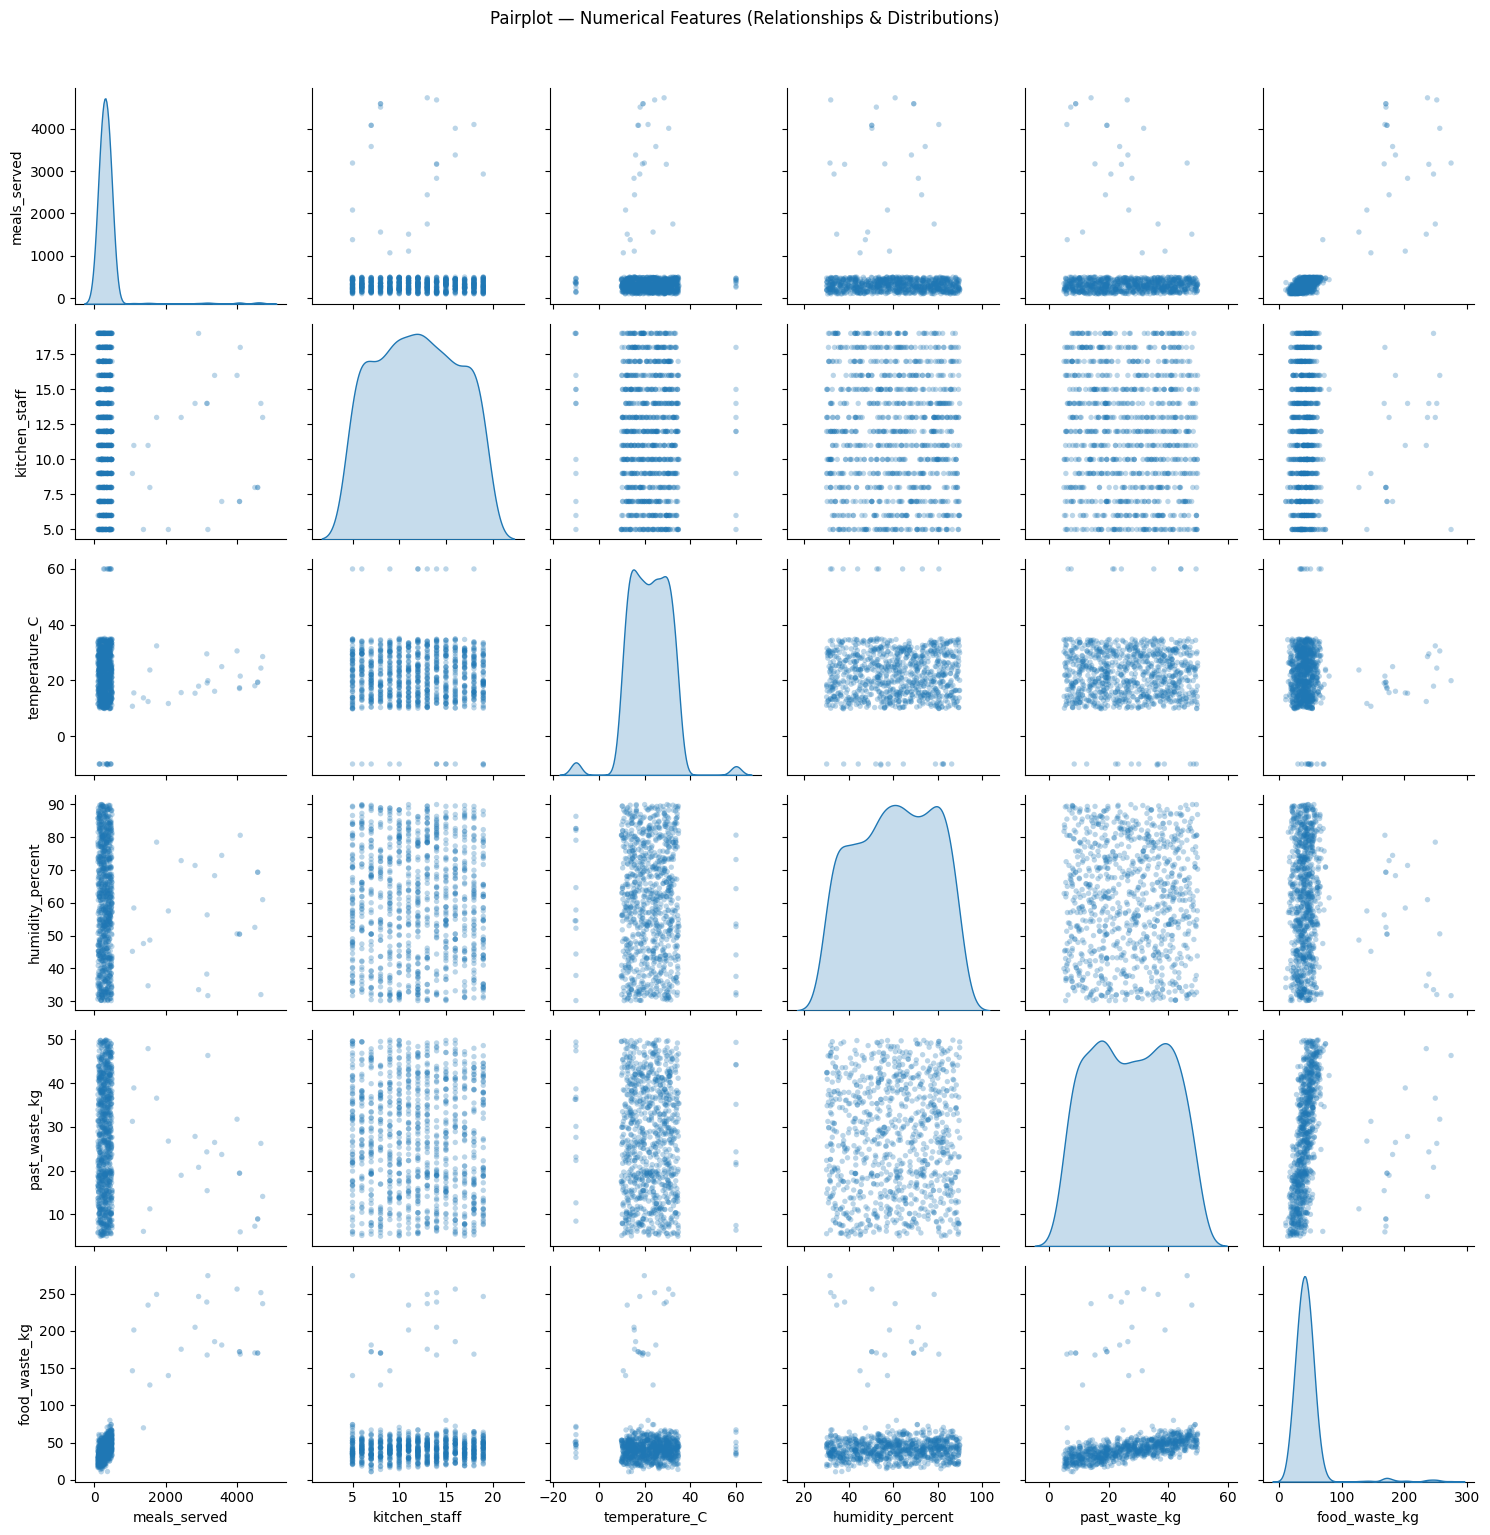

In [23]:
# Pairplot — relationships between all numerical features
pairplot_features = ['meals_served', 'kitchen_staff', 'temperature_C',
                     'humidity_percent', 'past_waste_kg', 'food_waste_kg']
sns.pairplot(train_raw[pairplot_features], diag_kind='kde',
             plot_kws={'alpha': 0.3, 's': 15, 'edgecolors': 'none'},
             diag_kws={'fill': True})
plt.suptitle('Pairplot — Numerical Features (Relationships & Distributions)', y=1.02)
plt.tight_layout()
plt.show()

#  Dataset Pre-processing

## Fault 1: Dirty Categorical Values (Case Inconsistency)

In [24]:
# Show the raw unique values before cleaning
print("waste_category unique values  :", train_raw['waste_category'].unique().tolist())
print("staff_experience unique values:", train_raw['staff_experience'].unique().tolist())

waste_category unique values  : ['dairy', 'MeAt', 'MEAT', 'Vegetables', 'GRAINS']
staff_experience unique values: ['intermediate', nan, 'Beginner', 'Intermediate', 'EXPERT']


In [25]:
df = train_raw.copy()

df['waste_category']    = df['waste_category'].str.strip().str.upper()
df['staff_experience']  = df['staff_experience'].str.strip().str.upper()

print("waste_category after cleaning  :", sorted(df['waste_category'].dropna().unique()))
print("staff_experience after cleaning:", sorted(df['staff_experience'].dropna().unique()))

waste_category after cleaning  : ['DAIRY', 'GRAINS', 'MEAT', 'VEGETABLES']
staff_experience after cleaning: ['BEGINNER', 'EXPERT', 'INTERMEDIATE']


## Fault 2: Null / Missing Values

In [26]:
print("Null value counts per column:")
print(df.isnull().sum())

Null value counts per column:
ID                    0
date                  0
meals_served          0
kitchen_staff         0
temperature_C         0
humidity_percent      0
day_of_week           0
special_event         0
past_waste_kg         0
staff_experience    164
waste_category        0
food_waste_kg         0
dtype: int64


In [27]:
mode_val = df['staff_experience'].mode()[0]
print(f"Mode of staff_experience: {mode_val}")

df['staff_experience'] = df['staff_experience'].fillna(mode_val)

print("\nNull values after imputation:")
print(df.isnull().sum())

Mode of staff_experience: INTERMEDIATE

Null values after imputation:
ID                  0
date                0
meals_served        0
kitchen_staff       0
temperature_C       0
humidity_percent    0
day_of_week         0
special_event       0
past_waste_kg       0
staff_experience    0
waste_category      0
food_waste_kg       0
dtype: int64


## Fault 3: Feature Scaling

In [28]:
# Feature engineering from date
df['date']    = pd.to_datetime(df['date'])
df['month']   = df['date'].dt.month
df['year']    = df['date'].dt.year
df['quarter'] = df['date'].dt.quarter
df.drop(columns=['date'], inplace=True)

# Drop ID column
df.drop(columns=['ID'], inplace=True)

# Label encode categorical columns
le_exp = LabelEncoder()
le_cat = LabelEncoder()
df['staff_experience'] = le_exp.fit_transform(df['staff_experience'])
df['waste_category']   = le_cat.fit_transform(df['waste_category'])

print("Encoding — staff_experience:", dict(zip(le_exp.classes_, le_exp.transform(le_exp.classes_))))
print("Encoding — waste_category  :", dict(zip(le_cat.classes_, le_cat.transform(le_cat.classes_))))
print("\nProcessed columns:", df.columns.tolist())
df.head()

Encoding — staff_experience: {'BEGINNER': np.int64(0), 'EXPERT': np.int64(1), 'INTERMEDIATE': np.int64(2)}
Encoding — waste_category  : {'DAIRY': np.int64(0), 'GRAINS': np.int64(1), 'MEAT': np.int64(2), 'VEGETABLES': np.int64(3)}

Processed columns: ['meals_served', 'kitchen_staff', 'temperature_C', 'humidity_percent', 'day_of_week', 'special_event', 'past_waste_kg', 'staff_experience', 'waste_category', 'food_waste_kg', 'month', 'year', 'quarter']


,meals_served,kitchen_staff,temperature_C,humidity_percent,day_of_week,special_event,past_waste_kg,staff_experience,waste_category,food_waste_kg,month,year,quarter
0,196,13,27.887273,45.362854,0,0,7.740587,2,0,28.946465,12,2022,4
1,244,15,10.317872,64.430475,1,0,42.311779,2,2,51.549053,11,2023,4
2,148,16,27.714300,69.046113,1,0,41.184305,0,2,53.008323,2,2022,1
3,157,19,19.173902,46.292823,6,0,41.543492,0,2,48.621527,3,2023,1
4,297,10,26.375233,79.741064,0,0,26.525097,2,2,44.156984,7,2022,3


# Dataset Splitting

In [29]:
TARGET = 'food_waste_kg'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# 80/20 split of train.csv for model development
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42
)

n_total = len(X)
print(f"Total training samples : {n_total}")
print(f"Train set              : {len(X_train):4d}  ({len(X_train)/n_total*100:.1f}%)")
print(f"Validation set         : {len(X_val):4d}  ({len(X_val)/n_total*100:.1f}%)")
print()
print("y_train stats:\n", y_train.describe())


Total training samples : 911
Train set              :  728  (79.9%)
Validation set         :  183  (20.1%)

y_train stats:
 count    728.000000
mean      45.495300
std       29.080174
min       10.819048
25%       33.003932
50%       41.429099
75%       50.386653
max      274.328783
Name: food_waste_kg, dtype: float64


In [30]:
# ── Pre-process test.csv the same way as train.csv ─────────────────────────
test_df = test_raw.copy()
test_df['waste_category']   = test_df['waste_category'].str.strip().str.upper()
test_df['staff_experience'] = test_df['staff_experience'].str.strip().str.upper()

# Impute missing values in test using same mode strategy
test_df['staff_experience'] = test_df['staff_experience'].fillna(test_df['staff_experience'].mode()[0])

# Date feature engineering
test_df['date']    = pd.to_datetime(test_df['date'])
test_df['month']   = test_df['date'].dt.month
test_df['year']    = test_df['date'].dt.year
test_df['quarter'] = test_df['date'].dt.quarter
test_df.drop(columns=['date'], inplace=True)

# Align test IDs for final evaluation
test_ids = test_df['ID'].values
test_df.drop(columns=['ID'], inplace=True)

# Encode categoricals using the SAME LabelEncoders fitted on train
test_df['staff_experience'] = le_exp.transform(test_df['staff_experience'])
test_df['waste_category']   = le_cat.transform(test_df['waste_category'])

X_test_external = test_df[X_train.columns]  # ensure column order matches

# ── Apply StandardScaler — fit ONLY on X_train ───────────────────────────────
scaler = StandardScaler()
X_train_scaled    = scaler.fit_transform(X_train)
X_val_scaled      = scaler.transform(X_val)
X_test_ext_scaled = scaler.transform(X_test_external)   # sealed until Section 6.7

print("Per-feature mean before scaling:", X_train.mean(axis=0).values.round(2))
print("Per-feature mean after  scaling:", X_train_scaled.mean(axis=0).round(2))
print("\nExternal test set shape:", X_test_external.shape)


Per-feature mean before scaling: [3.85520e+02 1.19400e+01 2.22000e+01 6.05100e+01 3.04000e+00 9.00000e-02
 2.71100e+01 1.39000e+00 1.62000e+00 5.85000e+00 2.02287e+03 2.29000e+00]
Per-feature mean after  scaling: [ 0.  0.  0.  0.  0.  0.  0.  0. -0.  0. -0.  0.]

External test set shape: (911, 12)


# Model Training & Testing (Supervised)

In [31]:
results = {}

def evaluate(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    results[name] = {"R2": r2, "MSE": mse, "RMSE": rmse, "MAE": mae}
    print(f"{name:30s}  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return y_pred

## Linear Regression

In [32]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_val_scaled)
lr_r2 = evaluate("Linear Regression", y_val, y_pred_lr)

print("\nTop 5 coefficients by magnitude:")
coef_df = pd.Series(lr_model.coef_, index=X_train.columns).abs().sort_values(ascending=False)
print(coef_df.head(5))

Linear Regression               R²=0.7476  RMSE=11.3728  MAE=5.4991

Top 5 coefficients by magnitude:
meals_served     25.714857
past_waste_kg     8.961476
special_event     3.465052
kitchen_staff     1.670761
quarter           1.329179
dtype: float64


##  Decision Tree

In [33]:
dt_model = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_val)
dt_r2 = evaluate("Decision Tree", y_val, y_pred_dt)

print(f"\nTree depth used : {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")

Decision Tree                   R²=0.8113  RMSE=9.8323  MAE=6.0820

Tree depth used : 8
Number of leaves: 65


##  Neural Network

Neural Network (MLP)            R²=0.8304  RMSE=9.3223  MAE=5.7813

Architecture : Input(12) → 128 → 64 → 32 → Output(1)
Epochs trained: 283


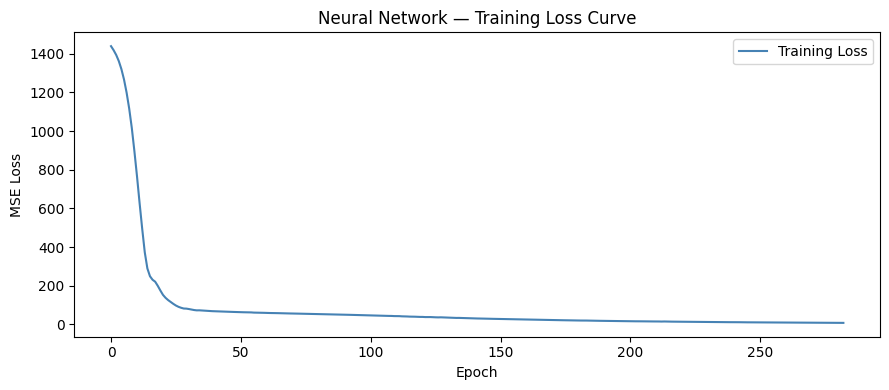

In [34]:
nn_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=500,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
nn_model.fit(X_train_scaled, y_train)
y_pred_nn = nn_model.predict(X_val_scaled)
nn_r2 = evaluate("Neural Network (MLP)", y_val, y_pred_nn)

print(f"\nArchitecture : Input({X_train.shape[1]}) → 128 → 64 → 32 → Output(1)")
print(f"Epochs trained: {nn_model.n_iter_}")

# Training loss curve
plt.figure(figsize=(9, 4))
plt.plot(nn_model.loss_curve_, label='Training Loss', color='steelblue')
plt.title("Neural Network — Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

##  KMeans Clustering (Unsupervised)

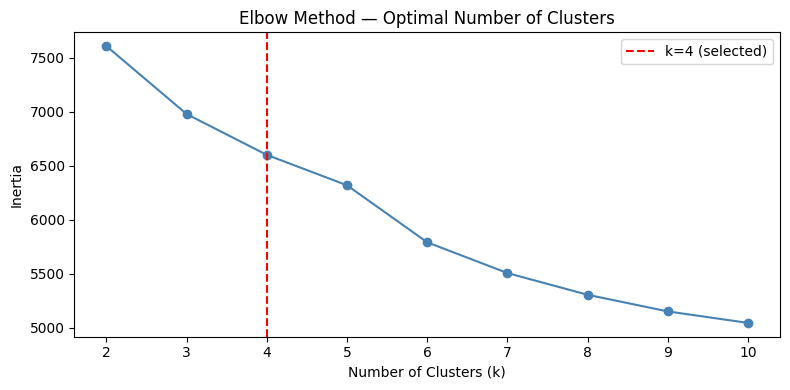

KMeans cluster counts: {0: 242, 1: 230, 2: 63, 3: 193}


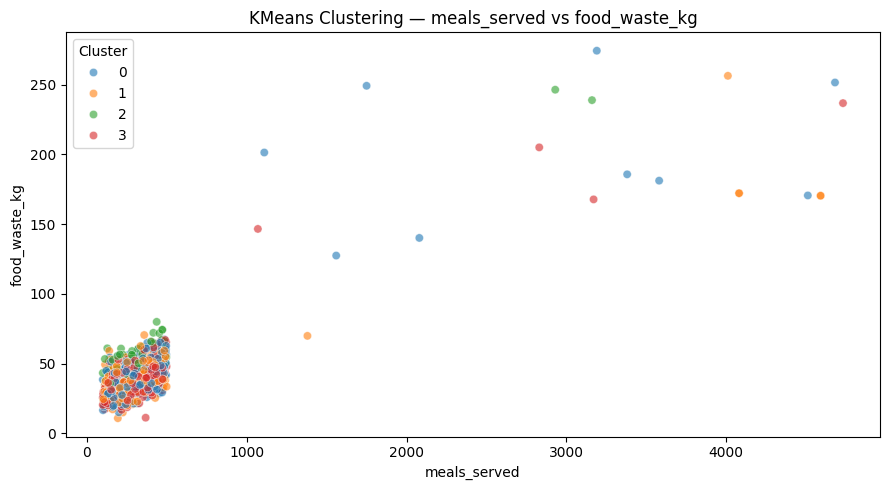

PCA variance explained: PC1=16.9%,  PC2=9.7%,  Total=26.6%


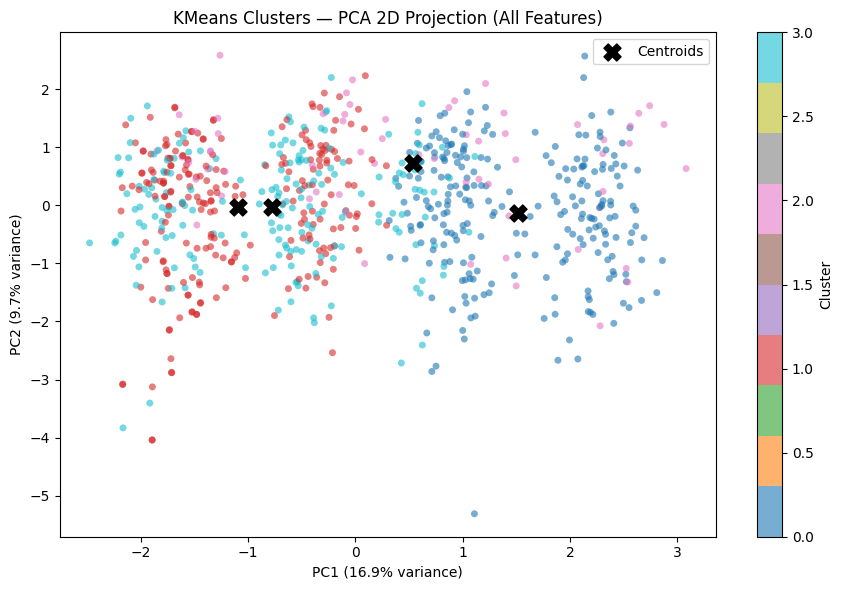

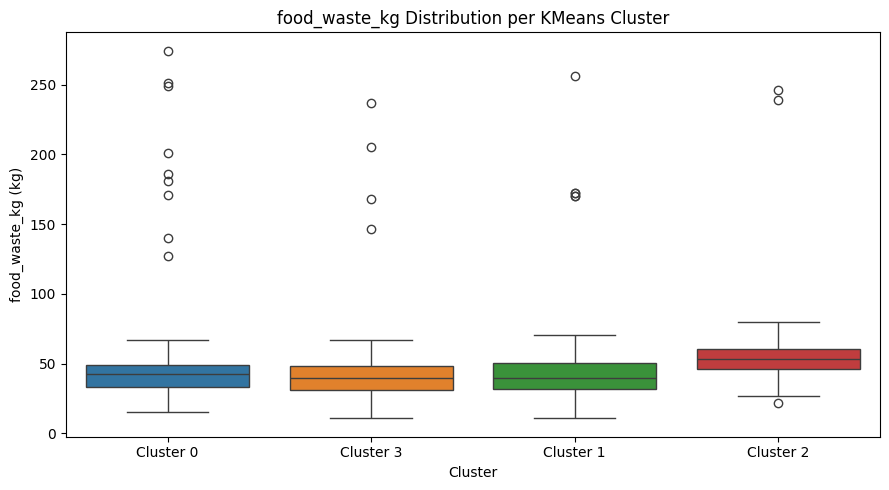


Cluster summary (food_waste_kg stats per cluster):
          mean  median  count    std
cluster                             
0        46.83   42.84    242  33.04
1        43.09   39.71    230  25.01
2        57.83   53.28     63  35.83
3        42.66   39.74    193  24.58


In [35]:
from sklearn.decomposition import PCA

# ── Elbow method to find optimal k ──────────────────────────────────────────
inertias = []
K_range  = range(2, 11)
for k in K_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tmp.fit(X_train_scaled)
    inertias.append(km_tmp.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', color='steelblue')
plt.axvline(4, linestyle='--', color='red', label='k=4 (selected)')
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.legend()
plt.tight_layout()
plt.show()

# ── Fit KMeans with k=4 ──────────────────────────────────────────────────────
kmeans   = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)
print("KMeans cluster counts:", pd.Series(clusters).value_counts().sort_index().to_dict())

# ── Plot 1: meals_served vs food_waste_kg coloured by cluster ────────────────
plt.figure(figsize=(9, 5))
sns.scatterplot(x=X_train['meals_served'], y=y_train,
                hue=clusters, palette='tab10', alpha=0.6)
plt.title("KMeans Clustering — meals_served vs food_waste_kg")
plt.xlabel("meals_served")
plt.ylabel("food_waste_kg")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# ── Plot 2: PCA 2D projection — all features ─────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_scaled)

var_explained = pca.explained_variance_ratio_ * 100
print(f"PCA variance explained: PC1={var_explained[0]:.1f}%,  PC2={var_explained[1]:.1f}%,  "
      f"Total={sum(var_explained):.1f}%")

plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=clusters, cmap='tab10', alpha=0.6, s=25, edgecolors='none')

# Plot cluster centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=150, zorder=5, label='Centroids')

plt.colorbar(scatter, label='Cluster')
plt.xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
plt.title("KMeans Clusters — PCA 2D Projection (All Features)")
plt.legend()
plt.tight_layout()
plt.show()

# ── Plot 3: Cluster-wise food_waste_kg distribution (boxplot) ────────────────
cluster_df = pd.DataFrame({
    'Cluster': [f'Cluster {c}' for c in clusters],
    'food_waste_kg': y_train.values
})

plt.figure(figsize=(9, 5))
sns.boxplot(data=cluster_df, x='Cluster', y='food_waste_kg', palette='tab10')
plt.title("food_waste_kg Distribution per KMeans Cluster")
plt.xlabel("Cluster")
plt.ylabel("food_waste_kg (kg)")
plt.tight_layout()
plt.show()

# ── Cluster summary table ────────────────────────────────────────────────────
cluster_summary = pd.DataFrame({'cluster': clusters, 'food_waste_kg': y_train.values})
print("\nCluster summary (food_waste_kg stats per cluster):")
print(cluster_summary.groupby('cluster')['food_waste_kg']
      .agg(['mean', 'median', 'count', 'std']).round(2))


##  K-Fold Cross Validation

In [36]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_models = {
    'Linear Regression':   (lr_model, X_train_scaled),
    'Decision Tree':       (dt_model, X_train.values),
    'Neural Network (MLP)':(nn_model, X_train_scaled),
}

cv_results_all = {}
print(f"{'Model':<30}  {'CV R² Mean':>12}  {'CV R² Std':>10}  {'CV RMSE Mean':>13}")
print("-" * 70)

for name, (model, X_cv) in cv_models.items():
    r2_scores_cv   = cross_val_score(model, X_cv, y_train, cv=kf, scoring='r2')
    rmse_scores_cv = np.sqrt(-cross_val_score(model, X_cv, y_train, cv=kf,
                                              scoring='neg_mean_squared_error'))
    cv_results_all[name] = {
        'CV R2 Mean' : round(r2_scores_cv.mean(), 4),
        'CV R2 Std'  : round(r2_scores_cv.std(),  4),
        'CV RMSE Mean': round(rmse_scores_cv.mean(), 4),
    }
    print(f"{name:<30}  {r2_scores_cv.mean():>12.4f}  {r2_scores_cv.std():>10.4f}  {rmse_scores_cv.mean():>13.4f}")

cv_df = pd.DataFrame(cv_results_all).T
print("\nK-Fold CV Summary Table:")
print(cv_df.to_string())

Model                             CV R² Mean   CV R² Std   CV RMSE Mean
----------------------------------------------------------------------
Linear Regression                     0.8301      0.0906        10.0847
Decision Tree                         0.7410      0.2705        11.4766
Neural Network (MLP)                  0.6749      0.1757        12.8639

K-Fold CV Summary Table:
                      CV R2 Mean  CV R2 Std  CV RMSE Mean
Linear Regression         0.8301     0.0906       10.0847
Decision Tree             0.7410     0.2705       11.4766
Neural Network (MLP)      0.6749     0.1757       12.8639


### K-Fold CV — Bar Chart (Mean R² ± Std)

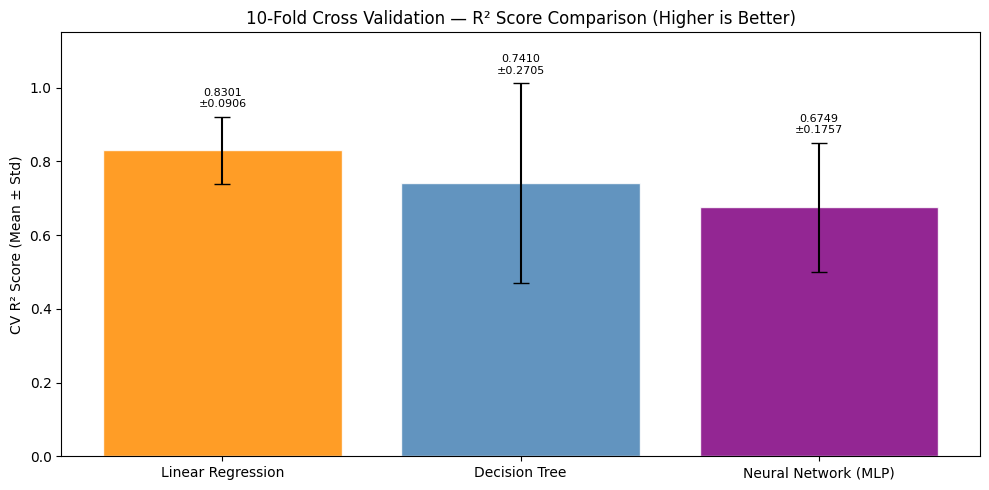


Interpretation:
  Best model by CV R²: Linear Regression
  Lower std = more stable/consistent across folds.


In [37]:
cv_names  = list(cv_results_all.keys())
cv_means  = [cv_results_all[n]['CV R2 Mean']  for n in cv_names]
cv_stds   = [cv_results_all[n]['CV R2 Std']   for n in cv_names]
cv_colors = ['darkorange', 'steelblue', 'purple']

plt.figure(figsize=(10, 5))
bars = plt.bar(cv_names, cv_means, yerr=cv_stds, color=cv_colors,
               capsize=6, edgecolor='white', alpha=0.85)
plt.ylabel('CV R² Score (Mean ± Std)')
plt.title('10-Fold Cross Validation — R² Score Comparison (Higher is Better)')
plt.ylim(0, 1.15)
for bar, m, s in zip(bars, cv_means, cv_stds):
    plt.text(bar.get_x() + bar.get_width()/2, m + s + 0.02,
             f'{m:.4f}\n±{s:.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
best_cv = max(cv_results_all, key=lambda n: cv_results_all[n]['CV R2 Mean'])
print(f"  Best model by CV R²: {best_cv}")
print(f"  Lower std = more stable/consistent across folds.")

#  Model Selection / Comparison Analysis

In [38]:
# Shared reference dict for all supervised models
all_models = {
    'Linear Regression':   (y_pred_lr, lr_model),
    'Decision Tree':       (y_pred_dt, dt_model),
    'Neural Network (MLP)':(y_pred_nn, nn_model),
}

model_names = list(all_models.keys())
r2_scores   = [results[n]['R2']   for n in model_names]
mse_scores  = [results[n]['MSE']  for n in model_names]
rmse_scores = [results[n]['RMSE'] for n in model_names]
mae_scores  = [results[n]['MAE']  for n in model_names]
colors      = ['darkorange', 'steelblue', 'purple']


##  R² Score — Bar Chart

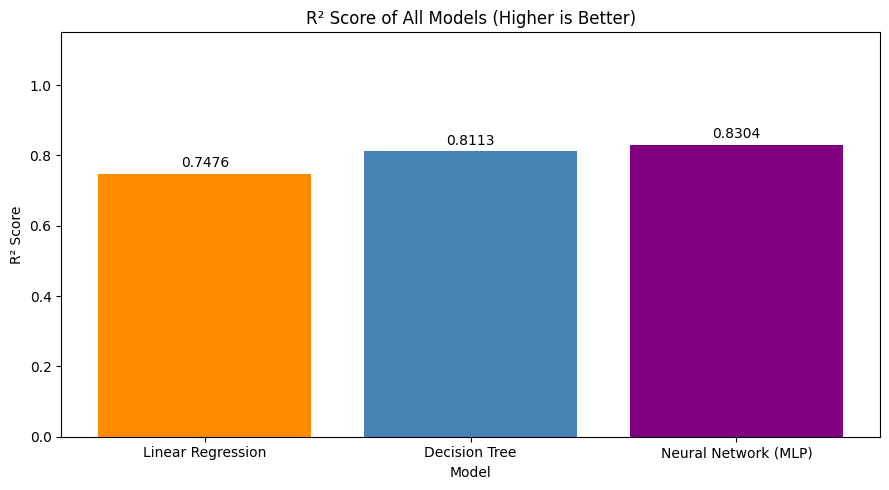

In [39]:
plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, r2_scores, color=colors)
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('R² Score of All Models (Higher is Better)')
plt.ylim(0, 1.15)
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, score + 0.01,
             f'{score:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

##  Loss Metrics — MSE, RMSE & MAE Comparison


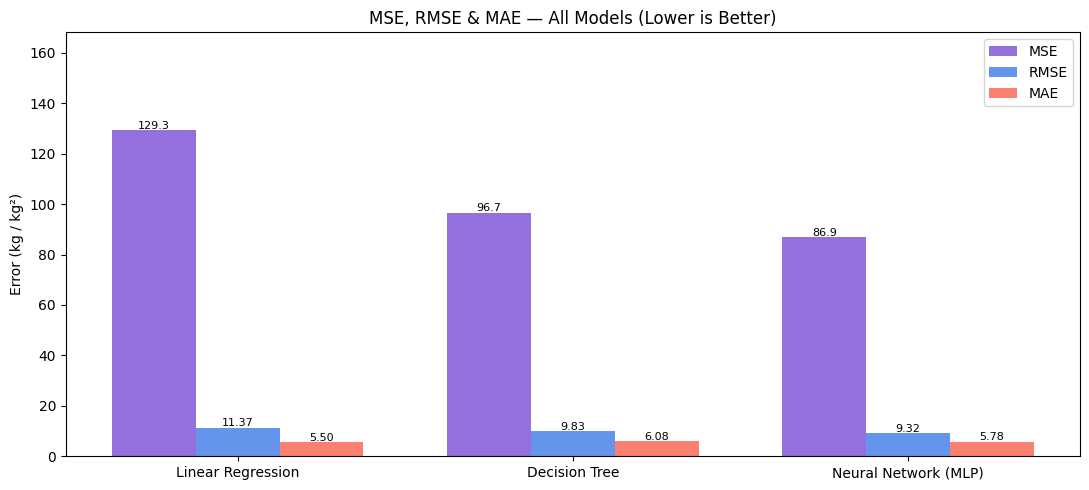

In [40]:
x_pos = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x_pos - width,     mse_scores,  width, label='MSE',  color='mediumpurple')
plt.bar(x_pos,             rmse_scores, width, label='RMSE', color='cornflowerblue')
plt.bar(x_pos + width,     mae_scores,  width, label='MAE',  color='salmon')
plt.xticks(x_pos, model_names)
plt.ylabel('Error (kg / kg²)')
plt.title('MSE, RMSE & MAE — All Models (Lower is Better)')
plt.ylim(0, max(mse_scores) * 1.3)
plt.legend()
for i, (ms, r, m) in enumerate(zip(mse_scores, rmse_scores, mae_scores)):
    plt.text(i - width,     ms + 0.5, f'{ms:.1f}',  ha='center', fontsize=8)
    plt.text(i,             r  + 0.5, f'{r:.2f}',   ha='center', fontsize=8)
    plt.text(i + width,     m  + 0.5, f'{m:.2f}',   ha='center', fontsize=8)
plt.tight_layout()
plt.show()


##  Actual vs Predicted

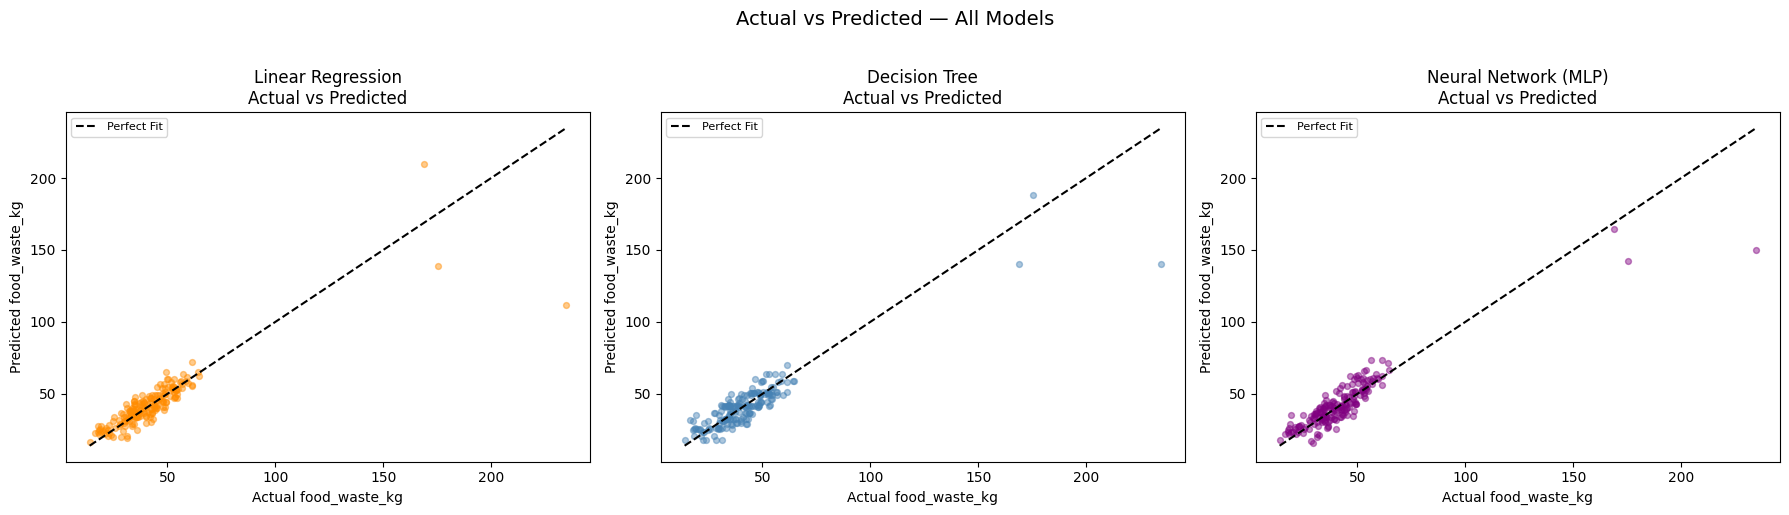

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for idx, (name, (preds, _)) in enumerate(all_models.items()):
    axes[idx].scatter(y_val, preds, alpha=0.45, s=18, color=colors[idx])
    mn, mx = y_val.min(), y_val.max()
    axes[idx].plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect Fit')
    axes[idx].set_xlabel("Actual food_waste_kg")
    axes[idx].set_ylabel("Predicted food_waste_kg")
    axes[idx].set_title(f'{name}\nActual vs Predicted')
    axes[idx].legend(fontsize=8)

plt.suptitle("Actual vs Predicted — All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

##  Residual Analysis

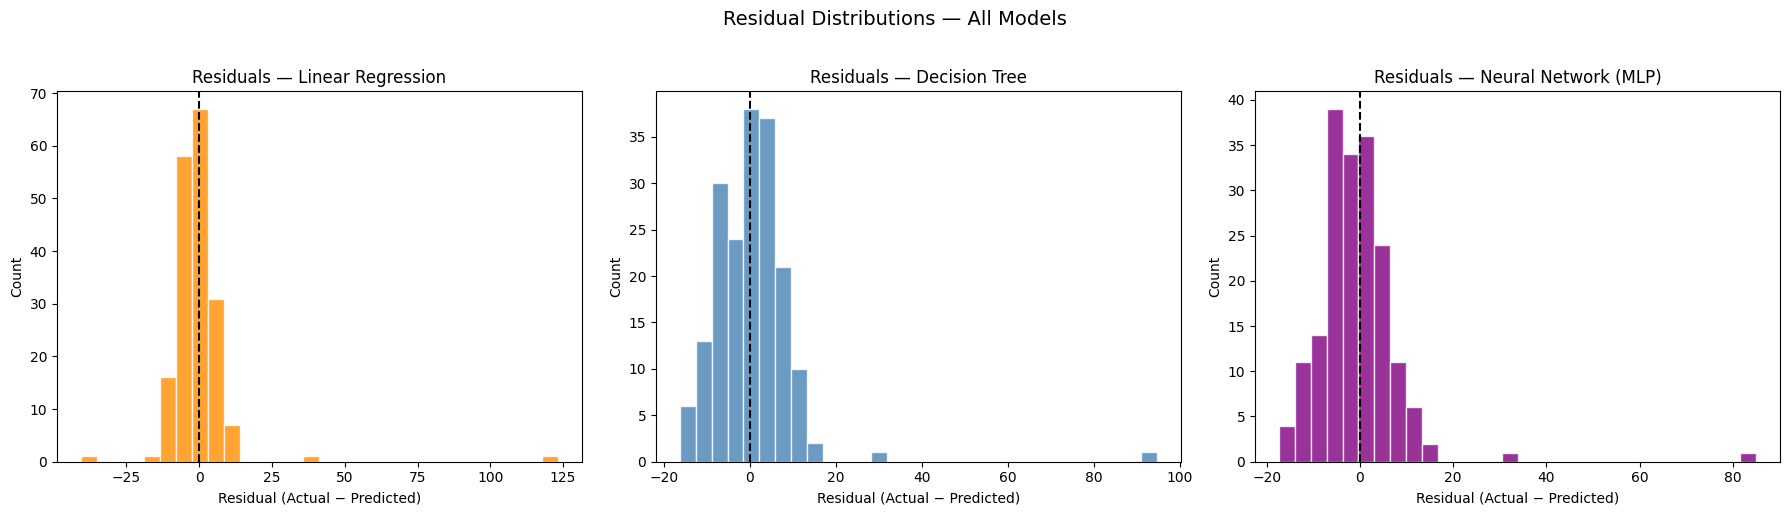

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for idx, (name, (preds, _)) in enumerate(all_models.items()):
    residuals = y_val.values - preds
    axes[idx].hist(residuals, bins=30, color=colors[idx], edgecolor='white', alpha=0.8)
    axes[idx].axvline(0, color='black', linestyle='--', lw=1.5)
    axes[idx].set_title(f'Residuals — {name}')
    axes[idx].set_xlabel("Residual (Actual − Predicted)")
    axes[idx].set_ylabel("Count")

plt.suptitle("Residual Distributions — All Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

##  Feature Importance (Decision Tree)

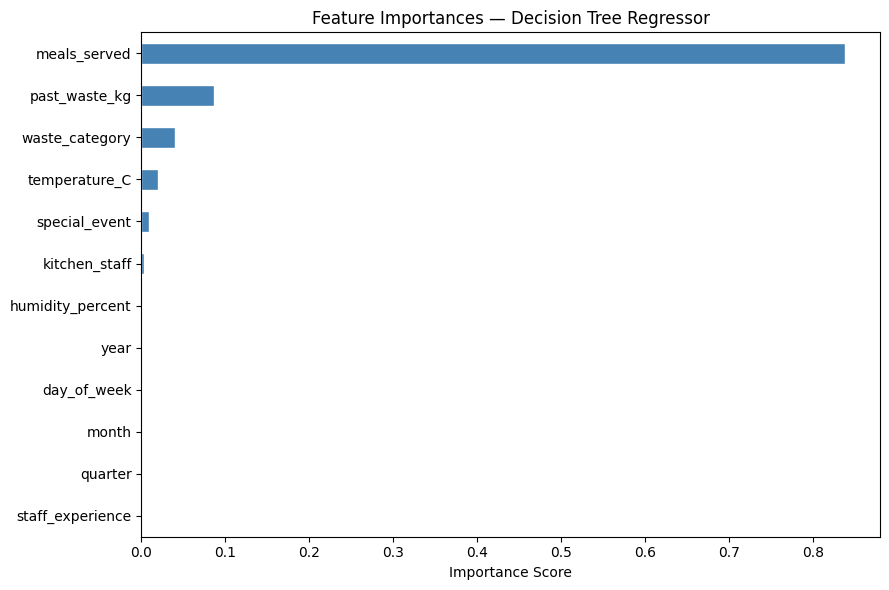

In [43]:
feat_imp = pd.Series(dt_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title("Feature Importances — Decision Tree Regressor")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

##  Summary Comparison Table

In [44]:
rows = []
for name, (preds, _) in all_models.items():
    r2   = r2_score(y_val, preds)
    mse  = mean_squared_error(y_val, preds)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_val, preds)
    rows.append({'Model': name,
                 'R² Score': round(r2, 4),
                 'MSE': round(mse, 4),
                 'RMSE': round(rmse, 4),
                 'MAE': round(mae, 4)})

summary_df = pd.DataFrame(rows).set_index('Model')
print(summary_df.to_string())
summary_df

                      R² Score       MSE     RMSE     MAE
Model                                                    
Linear Regression       0.7476  129.3400  11.3728  5.4991
Decision Tree           0.8113   96.6749   9.8323  6.0820
Neural Network (MLP)    0.8304   86.9051   9.3223  5.7813


,R² Score,MSE,RMSE,MAE
Model,,,,
Linear Regression,0.7476,129.3400,11.3728,5.4991
Decision Tree,0.8113,96.6749,9.8323,6.0820
Neural Network (MLP),0.8304,86.9051,9.3223,5.7813


In [45]:
# Best model selection based on validation R²
# The external test.csv + submission.csv will be used in Section 6.7
best_model_name = summary_df['R² Score'].idxmax()
print(f"Best model by validation R²: {best_model_name}")
print("Proceeding to final evaluation on external test.csv in Section 6.7.")


Best model by validation R²: Neural Network (MLP)
Proceeding to final evaluation on external test.csv in Section 6.7.


##  Final Evaluation on External Test Set (test.csv)

Best model (by validation R²): Neural Network (MLP)

── External Test Set Performance (test.csv) ────────────
  R²   : 0.9499
  MSE  : 39.0174
  RMSE : 6.2464
  MAE  : 3.8332

  Metric        Validation   External Test       Delta
  ----------------------------------------------------
  R²                0.8304          0.9499     +0.1195
  MSE              86.9051         39.0174    -47.8877
  RMSE              9.3223          6.2464     -3.0759
  MAE               5.7813          3.8332     -1.9481

  Verdict: well-generalised


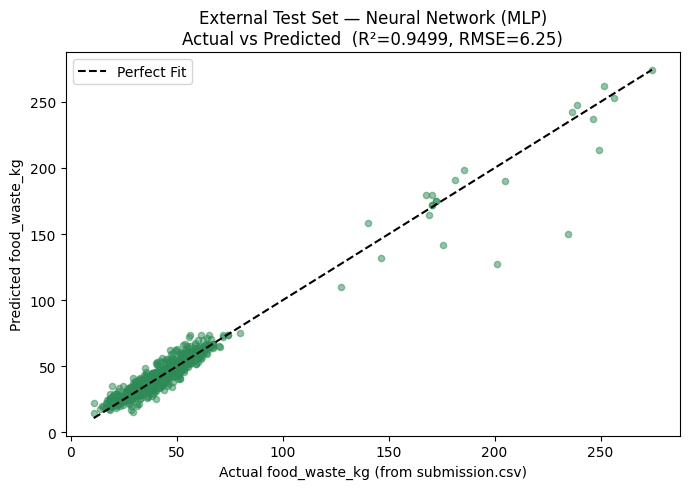

In [46]:
# ── Final evaluation on the external test set (test.csv + submission.csv) ───
best_model_name = summary_df['R² Score'].idxmax()
print(f"Best model (by validation R²): {best_model_name}")

# Predict on test.csv
if best_model_name == 'Linear Regression':
    y_pred_final = lr_model.predict(X_test_ext_scaled)
elif best_model_name == 'Decision Tree':
    y_pred_final = dt_model.predict(X_test_external)
else:
    y_pred_final = nn_model.predict(X_test_ext_scaled)

# Ground truth from submission.csv, aligned to test.csv row order
sub_indexed = submission.set_index('ID')
y_test_true = sub_indexed.loc[test_ids, 'food_waste_kg'].values

r2_final   = r2_score(y_test_true, y_pred_final)
mse_final  = mean_squared_error(y_test_true, y_pred_final)
rmse_final = np.sqrt(mse_final)
mae_final  = mean_absolute_error(y_test_true, y_pred_final)

print("\n── External Test Set Performance (test.csv) ────────────")
print(f"  R²   : {r2_final:.4f}")
print(f"  MSE  : {mse_final:.4f}")
print(f"  RMSE : {rmse_final:.4f}")
print(f"  MAE  : {mae_final:.4f}")
print()

# Compare val vs external test performance
val_r2   = summary_df.loc[best_model_name, 'R² Score']
val_mse  = summary_df.loc[best_model_name, 'MSE']
val_rmse = summary_df.loc[best_model_name, 'RMSE']
val_mae  = summary_df.loc[best_model_name, 'MAE']

print(f"  {'Metric':<10}  {'Validation':>12}  {'External Test':>14}  {'Delta':>10}")
print(f"  {'-'*52}")
print(f"  {'R²':<10}  {val_r2:>12.4f}  {r2_final:>14.4f}  {r2_final   - val_r2:>+10.4f}")
print(f"  {'MSE':<10}  {val_mse:>12.4f}  {mse_final:>14.4f}  {mse_final  - val_mse:>+10.4f}")
print(f"  {'RMSE':<10}  {val_rmse:>12.4f}  {rmse_final:>14.4f}  {rmse_final - val_rmse:>+10.4f}")
print(f"  {'MAE':<10}  {val_mae:>12.4f}  {mae_final:>14.4f}  {mae_final  - val_mae:>+10.4f}")
delta_r2 = r2_final - val_r2
print()
print(f"  Verdict: {'slight overfit' if delta_r2 < -0.02 else 'well-generalised'}")

# Scatter: Actual vs Predicted on external test
plt.figure(figsize=(7, 5))
plt.scatter(y_test_true, y_pred_final, alpha=0.5, s=20, color='seagreen')
mn, mx = y_test_true.min(), y_test_true.max()
plt.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect Fit')
plt.xlabel('Actual food_waste_kg (from submission.csv)')
plt.ylabel('Predicted food_waste_kg')
plt.title(f'External Test Set — {best_model_name}\nActual vs Predicted  (R²={r2_final:.4f}, RMSE={rmse_final:.2f})')
plt.legend()
plt.tight_layout()
plt.show()
